Iniciando a Análise Climática MENSAL em ambiente Colab. 📊
Tentando montar o Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montado com sucesso.

         CONFIGURAÇÃO DA CIDADE DE COMPARAÇÃO
         (A cidade base (A) é Sorocaba)
ATENÇÃO: A cidade base (A) é Sorocaba e seu arquivo é 'tabela_Sorocaba.csv'
Você precisará fornecer o nome do arquivo CSV e o nome da Cidade B.
1. Digite o NOME EXATO do arquivo CSV da Cidade B no seu Google Drive (ex: tabela_Passos_MG.csv): Salto.csv
2. Digite o NOME COMPLETO da Cidade B para o gráfico e lookup (ex: Passos (MG)): Salto

-> Cidade 'Salto' não encontrada na lista automática (C.4).
   Por favor, insira manualmente a distância e direção para o relatório.
3. Digite a distância APROXIMADA em linha reta (ex: 500 ou 500 km): 37
4. Digite a direção (ex: Nordeste (NE)): Nordeste (NE)

-> Dados de distância e direção preenchidos manualmente.



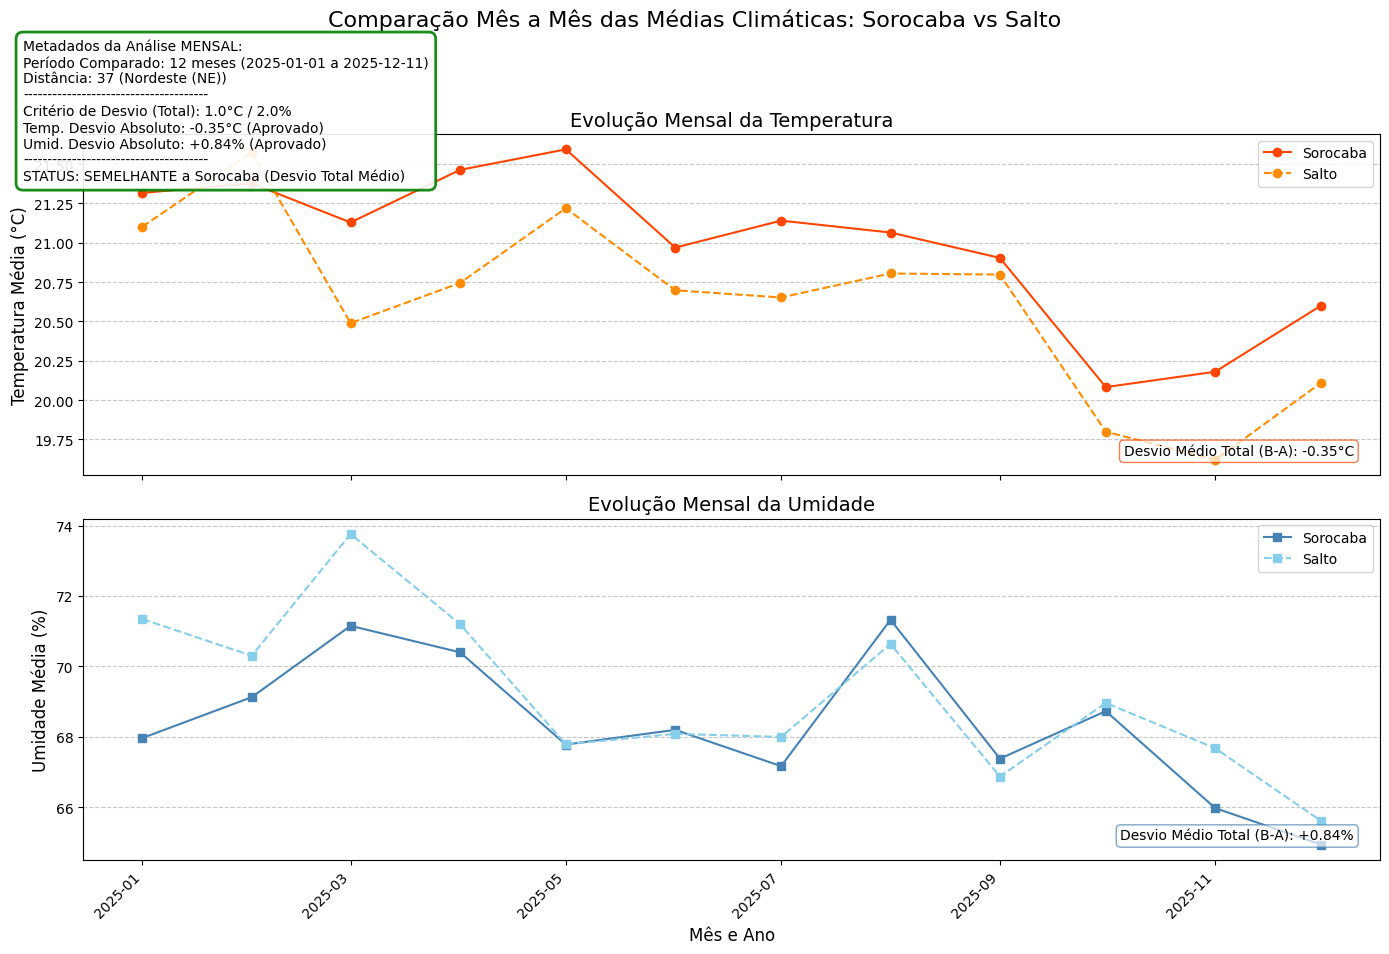

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates # Necessário para formatar o eixo X do gráfico de linha
# Importações necessárias para o ambiente Google Colab
from google.colab import drive
import os

# --- 1. CONFIGURAÇÕES E CAMINHOS (ENTRADA DINÂMICA) ---

# C.1: Caminho do arquivo base (Sorocaba é a base A)
ARQUIVO_CIDADE_A = '/content/drive/MyDrive/Colab Notebooks/Estagio/tabela_Sorocaba.csv'
NOME_CIDADE_A = 'Sorocaba'

# C.2: NOMES REAIS DAS COLUNAS DE TEMPERATURA E UMIDADE
COLUNA_TEMP = 'Temp. Ins. (C)'
COLUNA_UMID = 'Umi. Ins. (%)'

# C.3: LIMITES DE DESVIO PARA APROVAÇÃO (CRITÉRIOS SOLICITADOS)
# OBS: Estes limites não serão usados na análise mensal (que é apenas comparativa),
# mas mantidos para fins de referência de desvio.
LIMITE_TEMP_DESVIO_C = 1.0 # Limite de desvio de Temperatura em Celsius
LIMITE_UMID_DESVIO_PCT = 2.0 # Limite de desvio de Umidade em pontos percentuais

# C.4: METADADOS PREDEFINIDOS PARA CIDADES (CIDADE B em relação a Sorocaba)
CIDADES_METADADOS = {
    'Passos (MG)': {'distancia': 330, 'direcao': 'Norte/Nordeste (N/NE)'},
    'Juiz de Fora': {'distancia': 420, 'direcao': 'Leste (L)'},
    # Adicione suas outras cidades aqui
}

# Arquivo de saída para as médias mensais
ARQUIVO_SAIDA_MENSAL = 'medias_comparativas_mensais.csv'

# Variáveis globais para dados de entrada (Serão preenchidas via input ou lookup)
ARQUIVO_CIDADE_B = None
NOME_CIDADE_B = None
DISTANCIA_KM = None
DIRECAO_ROSA_VENTOS = None

# --- 2. FUNÇÕES DE ANÁLISE ---

def calcular_medias_mensais_e_diferencas(df_a, df_b, nome_a, nome_b):
    """
    Calcula as médias aritméticas mensais e as diferenças (Absoluta e Percentual)
    mês a mês entre as cidades.
    """
    # 1. Preparação: Cria a coluna de Mês/Ano (para agrupar)
    df_a['Mes_Ano'] = df_a['Data'].dt.to_period('M')
    df_b['Mes_Ano'] = df_b['Data'].dt.to_period('M')

    # 2. Cálculo das Médias Mensais (ignora NaN's)
    medias_a = df_a.groupby('Mes_Ano')[[COLUNA_TEMP, COLUNA_UMID]].mean().reset_index()
    medias_b = df_b.groupby('Mes_Ano')[[COLUNA_TEMP, COLUNA_UMID]].mean().reset_index()

    # 3. Mesclar (Merge) as médias para comparação
    df_comparativo = pd.merge(
        medias_a, medias_b,
        on='Mes_Ano',
        how='inner', # Apenas meses presentes em AMBOS os DataFrames
        suffixes=(f'_{nome_a}', f'_{nome_b}')
    )

    # Converte 'Mes_Ano' de Period para string para o arquivo CSV e para DateTime para o gráfico
    df_comparativo['Mes'] = df_comparativo['Mes_Ano'].dt.strftime('%Y-%m')
    df_comparativo['Data_Plot'] = df_comparativo['Mes_Ano'].dt.to_timestamp()

    # 4. Cálculo das Diferenças Mês a Mês
    temp_a_col = f'{COLUNA_TEMP}_{nome_a}'
    temp_b_col = f'{COLUNA_TEMP}_{nome_b}'
    umid_a_col = f'{COLUNA_UMID}_{nome_a}'
    umid_b_col = f'{COLUNA_UMID}_{nome_b}'

    # Diferença ABSOLUTA (B - A)
    df_comparativo['Desvio_Temp_Abs'] = df_comparativo[temp_b_col] - df_comparativo[temp_a_col]
    df_comparativo['Desvio_Umid_Abs'] = df_comparativo[umid_b_col] - df_comparativo[umid_a_col]

    # Diferença PERCENTUAL (B em relação a A)
    df_comparativo['Desvio_Temp_Pct'] = (df_comparativo['Desvio_Temp_Abs'] / df_comparativo[temp_a_col]) * 100
    df_comparativo['Desvio_Umid_Pct'] = (df_comparativo['Desvio_Umid_Abs'] / df_comparativo[umid_a_col]) * 100

    # Seleciona e renomeia as colunas para o CSV de saída
    colunas_saida = [
        'Mes',
        temp_a_col,
        temp_b_col,
        'Desvio_Temp_Abs',
        'Desvio_Temp_Pct',
        umid_a_col,
        umid_b_col,
        'Desvio_Umid_Abs',
        'Desvio_Umid_Pct',
        'Data_Plot' # Mantém para plotagem
    ]

    df_saida = df_comparativo[colunas_saida].copy()

    # Cria a média geral de desvio (B-A) para a caixa de texto
    media_desvio_temp_geral = df_saida['Desvio_Temp_Abs'].mean()
    media_desvio_umid_geral = df_saida['Desvio_Umid_Abs'].mean()

    return df_saida, media_desvio_temp_geral, media_desvio_umid_geral

def gerar_grafico_mensal(df_mensal, media_temp, media_umid, periodo_coleta, distancia, direcao):
    """
    Gera dois gráficos de linha comparativos, mostrando a evolução das médias mensais.
    """
    data_plot = df_mensal['Data_Plot']

    # --- Configuração da Figure com 2 Subplots (Temperatura e Umidade) ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f'Comparação Mês a Mês das Médias Climáticas: {NOME_CIDADE_A} vs {NOME_CIDADE_B}', fontsize=16, y=0.95)

    # --- Gráfico 1: Temperatura ---
    temp_a_col = f'{COLUNA_TEMP}_{NOME_CIDADE_A}'
    temp_b_col = f'{COLUNA_TEMP}_{NOME_CIDADE_B}'

    ax1.plot(data_plot, df_mensal[temp_a_col], marker='o', linestyle='-', color='orangered', label=f'{NOME_CIDADE_A}')
    ax1.plot(data_plot, df_mensal[temp_b_col], marker='o', linestyle='--', color='darkorange', label=f'{NOME_CIDADE_B}')

    ax1.set_ylabel('Temperatura Média (°C)', fontsize=12)
    ax1.set_title('Evolução Mensal da Temperatura', fontsize=14)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    ax1.legend(loc='upper right')

    # Adiciona a média geral de desvio (B-A)
    ax1.text(0.98, 0.05, f"Desvio Médio Total (B-A): {media_temp:+.2f}°C",
             transform=ax1.transAxes, fontsize=10, ha='right', va='bottom',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7, ec="orangered"))

    # --- Gráfico 2: Umidade ---
    umid_a_col = f'{COLUNA_UMID}_{NOME_CIDADE_A}'
    umid_b_col = f'{COLUNA_UMID}_{NOME_CIDADE_B}'

    ax2.plot(data_plot, df_mensal[umid_a_col], marker='s', linestyle='-', color='steelblue', label=f'{NOME_CIDADE_A}')
    ax2.plot(data_plot, df_mensal[umid_b_col], marker='s', linestyle='--', color='skyblue', label=f'{NOME_CIDADE_B}')

    ax2.set_xlabel('Mês e Ano', fontsize=12)
    ax2.set_ylabel('Umidade Média (%)', fontsize=12)
    ax2.set_title('Evolução Mensal da Umidade', fontsize=14)
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    ax2.legend(loc='upper right')

    # Adiciona a média geral de desvio (B-A)
    ax2.text(0.98, 0.05, f"Desvio Médio Total (B-A): {media_umid:+.2f}%",
             transform=ax2.transAxes, fontsize=10, ha='right', va='bottom',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7, ec="steelblue"))

    # --- Formatação do Eixo X (Comum aos dois gráficos) ---
    # Mostra Ano e Mês no eixo X
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45, ha='right')

    # --- Metadados e Status de Desvio Total (Caixa de Texto Geral) ---
    # Lógica de Aprovação (usando o desvio médio GERAL para o status)
    aprovado_temp = abs(media_temp) <= LIMITE_TEMP_DESVIO_C
    aprovado_umid = abs(media_umid) <= LIMITE_UMID_DESVIO_PCT

    if aprovado_temp and aprovado_umid:
        status_final = f"STATUS: SEMELHANTE a {NOME_CIDADE_A} (Desvio Total Médio)"
        status_cor = "green"
    else:
        status_final = f"STATUS: NÃO SEMELHANTE a {NOME_CIDADE_A} (Desvio Total Médio)"
        status_cor = "red"

    # Exibe ' km' apenas se a distância for um número
    distancia_display = f"{distancia} km" if isinstance(distancia, (int, float)) else distancia

    # Texto de metadados e status
    texto_analise_geral = (
        f"Metadados da Análise MENSAL:\n"
        f"Período Comparado: {len(df_mensal)} meses ({periodo_coleta})\n"
        f"Distância: {distancia_display} ({direcao})\n"
        f"--------------------------------------\n"
        f"Critério de Desvio (Total): {LIMITE_TEMP_DESVIO_C}°C / {LIMITE_UMID_DESVIO_PCT}%\n"
        f"Temp. Desvio Absoluto: {media_temp:+.2f}°C ({'Aprovado' if aprovado_temp else 'Reprovado'})\n"
        f"Umid. Desvio Absoluto: {media_umid:+.2f}% ({'Aprovado' if aprovado_umid else 'Reprovado'})\n"
        f"--------------------------------------\n"
        f"{status_final}"
    )

    # Adiciona a caixa de texto no canto superior esquerdo da figura
    fig.text(0.02, 0.92, texto_analise_geral, transform=fig.transFigure,
             fontsize=10, verticalalignment='top', horizontalalignment='left',
             bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.9, ec=status_cor, lw=2))

    # Salva e exibe o gráfico
    plt.tight_layout(rect=[0, 0, 1, 0.9]) # Ajusta para dar espaço ao suptitle e caixa de texto
    plt.savefig('comparacao_climatica_mensal_linhas.png')
    plt.show()

# --- 3. FLUXO PRINCIPAL DO PROGRAMA ---

def obter_dados_cidade_b():
    """
    Solicita o nome do arquivo e o nome da Cidade B ao usuário.
    (Função mantida da versão anterior, apenas adaptada para o novo contexto)
    """
    print("\n" + "="*50)
    print("         CONFIGURAÇÃO DA CIDADE DE COMPARAÇÃO")
    print("         (A cidade base (A) é Sorocaba)")
    print("="*50)

    global ARQUIVO_CIDADE_B, NOME_CIDADE_B, DISTANCIA_KM, DIRECAO_ROSA_VENTOS

    print(f"ATENÇÃO: A cidade base (A) é {NOME_CIDADE_A} e seu arquivo é '{os.path.basename(ARQUIVO_CIDADE_A)}'")
    print("Você precisará fornecer o nome do arquivo CSV e o nome da Cidade B.")

    # 1. Nome do arquivo (EXIGIDO)
    ARQUIVO_CIDADE_B_NOME = input(
        "1. Digite o NOME EXATO do arquivo CSV da Cidade B no seu Google Drive (ex: tabela_Passos_MG.csv): "
    )
    # Monta o caminho completo no Drive (assumindo o mesmo diretório base)
    ARQUIVO_CIDADE_B = os.path.dirname(ARQUIVO_CIDADE_A) + "/" + ARQUIVO_CIDADE_B_NOME

    # 2. Nome da cidade (EXIGIDO para Lookup)
    NOME_CIDADE_B = input(
        "2. Digite o NOME COMPLETO da Cidade B para o gráfico e lookup (ex: Passos (MG)): "
    )

    # Tentativa de preenchimento automático
    nome_lookup = NOME_CIDADE_B.strip()

    metadado = CIDADES_METADADOS.get(nome_lookup)

    if metadado:
        # AUTOMÁTICO: Cidade encontrada na lista
        DISTANCIA_KM = metadado['distancia']
        DIRECAO_ROSA_VENTOS = metadado['direcao']
        print(f"\n-> Metadados de distância e direção preenchidos automaticamente para '{nome_lookup}'.")
    else:
        # MANUAL: Cidade não encontrada, solicita os dados
        print(f"\n-> Cidade '{NOME_CIDADE_B}' não encontrada na lista automática (C.4).")
        print("   Por favor, insira manualmente a distância e direção para o relatório.")

        # 3. Distância em linha reta (Solicita agora)
        DISTANCIA_KM = input(
            "3. Digite a distância APROXIMADA em linha reta (ex: 500 ou 500 km): "
        )
        # 4. Direção (Solicita agora)
        DIRECAO_ROSA_VENTOS = input(
            "4. Digite a direção (ex: Nordeste (NE)): "
        )

        print("\n-> Dados de distância e direção preenchidos manualmente.")

    print("="*50 + "\n")


print("Iniciando a Análise Climática MENSAL em ambiente Colab. 📊")

# 3.1. Montagem do Google Drive
try:
    print("Tentando montar o Google Drive...")
    drive.mount('/content/drive')
    print("Google Drive montado com sucesso.")
except Exception as e:
    print(f"ERRO ao montar o Drive: {e}. Verifique se está no Google Colab.")

# 3.2. Solicita os dados da Cidade B
obter_dados_cidade_b()

try:
    # 3.3. Leitura dos Dados
    df_a = pd.read_csv(ARQUIVO_CIDADE_A, sep=';', decimal=',')
    df_b = pd.read_csv(ARQUIVO_CIDADE_B, sep=';', decimal=',')

    print("\n--- Dados de Entrada Lidos com Sucesso ---")

    # 3.4. Processamento de Data e Limpeza
    # Conversão da coluna de data (aplicada a ambos)
    df_a['Data'] = pd.to_datetime(df_a['Data'], errors='coerce')
    df_b['Data'] = pd.to_datetime(df_b['Data'], errors='coerce')

    # Remove registros onde a data é inválida
    df_a.dropna(subset=['Data'], inplace=True)
    df_b.dropna(subset=['Data'], inplace=True)

    # NOVO: A contagem de dados válidos agora é feita ANTES do agrupamento
    contagem_temp_a = df_a[COLUNA_TEMP].count()
    contagem_umid_a = df_a[COLUNA_UMID].count()

    contagem_temp_b = df_b[COLUNA_TEMP].count()
    contagem_umid_b = df_b[COLUNA_UMID].count()

    # Cálculo do Período de Coleta GERAL
    data_inicio_a = df_a['Data'].min().strftime('%Y-%m-%d')
    data_fim_a = df_a['Data'].max().strftime('%Y-%m-%d')
    data_inicio_b = df_b['Data'].min().strftime('%Y-%m-%d')
    data_fim_b = df_b['Data'].max().strftime('%Y-%m-%d')

    if data_inicio_a == data_inicio_b and data_fim_a == data_fim_b:
        periodo_coleta = f"{data_inicio_a} a {data_fim_a}"
    else:
        periodo_coleta = f"{NOME_CIDADE_A}: {data_inicio_a} a {data_fim_a} | {NOME_CIDADE_B}: {data_inicio_b} a {data_fim_b}"

    print(f"\n--- Metadados da Coleta Bruta ---")
    print(f"Contagem Válida de Dados ({NOME_CIDADE_A}): Temp: {contagem_temp_a} | Umid: {contagem_umid_a}")
    print(f"Contagem Válida de Dados ({NOME_CIDADE_B}): Temp: {contagem_temp_b} | Umid: {contagem_umid_b}")
    print(f"Período de Coleta Bruta: {periodo_coleta}")
    print(f"Distância: {DISTANCIA_KM} km | Direção: {DIRECAO_ROSA_VENTOS}\n")

    # 3.5. Cálculo das Médias Mensais e Diferenças
    df_mensal, media_desvio_temp, media_desvio_umid = calcular_medias_mensais_e_diferencas(
        df_a, df_b, NOME_CIDADE_A, NOME_CIDADE_B
    )

    # 3.6. Salvamento da Tabela de Médias Mensais (Remove 'Data_Plot' antes de salvar)
    df_saida_final = df_mensal.drop(columns=['Data_Plot'])
    df_saida_final.to_csv(ARQUIVO_SAIDA_MENSAL, index=False)

    print(f"--- Tabela de Médias e Desvios Mensais Salva ({ARQUIVO_SAIDA_MENSAL}) ---")
    print(f"Meses comparados em comum: {len(df_mensal)}")
    print(df_saida_final.head().to_markdown(index=False)) # Exibe apenas o cabeçalho
    print("...\n")

    # 3.7. Geração do Gráfico e Relatório Final
    gerar_grafico_mensal(
        df_mensal,
        media_desvio_temp,
        media_desvio_umid,
        periodo_coleta,
        DISTANCIA_KM,
        DIRECAO_ROSA_VENTOS
    )

except FileNotFoundError:
    print(f"\nERRO: Um ou mais arquivos CSV não foram encontrados.")
    print(f"Verifique o caminho: '{ARQUIVO_CIDADE_A}' e '{ARQUIVO_CIDADE_B}'")
except KeyError as e:
    print(f"\nERRO: Coluna não encontrada. A coluna '{e}' pode estar faltando ou com o nome errado.")
    print(f"Verifique as colunas de temperatura ('{COLUNA_TEMP}') e umidade ('{COLUNA_UMID}').")
except Exception as e:
    print(f"\nOcorreu um erro inesperado: {e}")